# Exercícios

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

## 1.

Carregue o conjunto de dados "breast_cancer" usando a função "load_breast_cancer()".


In [ ]:
#load data
cancer = load_breast_cancer()

## 2.

Faça uma divisão treino/teste com os valores por omissão (treino=75%, teste=25%).

In [ ]:
#split data
X_train, X_test, y_train, y_test = train_test_split(
	cancer.data, cancer.target, stratify=cancer.target, random_state=0)

## 3.

Construa um modelo usando Random Forest com os valores por omissão. Calcule o desempenho
sobre ambos os conjuntos. Existem evidências de sobre-ajustamento? Como pode tentar reduzi-lo?

In [ ]:
rf = RandomForestClassifier(random_state=0)
rf.fit(X_train, y_train)

exatidao_treino = rf.score(X_train, y_train)
exatidao_teste = rf.score(X_test, y_test)

print("Exatidão de Treino:", exatidao_treino, "\nExatidão de Teste:", exatidao_teste)

Exatidão de Treino: 0.9976525821596244 
Exatidão de Teste: 0.9440559440559441


Indica sobreajustamento visto que a exatidão do treino está muito próxima de 1.

O sobreajustamento pode ser reduzido ao: 
- Diminuir a profundidade das árvores (max_depth); 
- Reduzir o número de atributos testados (max_features); 
- Aumentar o número de árvores para maior estabilidade (n_estimators).

## 4.

Construa novos modelos alterando o nº de atributos testados e/ou aplicando pré-poda. Compare o
desempenho entre os vários modelos construídos.

In [ ]:
n_features = [1, 2, 3, 5, 7, 10]
n_depth = [1, 3, 5]
lista_features = []
lista_depth = []
exatidao_treino = []
exatidao_teste = []

for m in n_depth:
    for n in n_features:
        #build model
        rf = RandomForestClassifier(max_features=n, max_depth=m, random_state=0)
        #train model
        rf.fit(X_train, y_train)
        #metrics
        lista_features.append(n)
        lista_depth.append(m)
        exatidao_treino.append(rf.score(X_train, y_train))
        exatidao_teste.append(rf.score(X_test, y_test))
    
#tabela com resultados
df = pd.DataFrame({
    "N_features": lista_features,
    "Max_depth": lista_depth,
    "Exatidao_treino": exatidao_treino,
    "Exatidao_teste": exatidao_teste
})

print(df.to_string(index=False))

 N_features  Max_depth  Exatidao_treino  Exatidao_teste
          1          1         0.924883        0.909091
          2          1         0.927230        0.902098
          3          1         0.931925        0.909091
          5          1         0.936620        0.923077
          7          1         0.938967        0.930070
         10          1         0.938967        0.916084
          1          3         0.981221        0.930070
          2          3         0.978873        0.930070
          3          3         0.981221        0.923077
          5          3         0.988263        0.944056
          7          3         0.985915        0.937063
         10          3         0.981221        0.944056
          1          5         0.995305        0.930070
          2          5         0.995305        0.944056
          3          5         0.997653        0.944056
          5          5         0.997653        0.944056
          7          5         0.997653        0

## 5.

Confirme a implementação do algoritmo Extra Randomized Trees no sklearn. Que parâmetros
permitem influenciar a diversidade das árvores geradas? Qual o valor por omissão e o que significa?


**Parâmetros que Influenciam a diversidade das árvores geradas:**

**max_features:** Número de atributos testados. 

(***Valor por Omissão: max_features = "sqrt", significa que testa a raíz do número de atributos)***

**n_estimators:** Número de árvores.

**bootstrap:** Amostragem com reposição.

## 6.

Crie um modelo ERT com os valores por omissão. Qual o desempenho obtido?

In [ ]:
ert = ExtraTreesClassifier(random_state=0)
ert.fit(X_train, y_train)

exatidao_treino = ert.score(X_train, y_train)
exatidao_teste = ert.score(X_test, y_test)

print("Exatidão de Treino:", exatidao_treino, "\nExatidão de Teste:", exatidao_teste)

Exatidão de Treino: 1.0 
Exatidão de Teste: 0.9440559440559441


## 7.

Construa um modelo usando Gradient Boosting Trees com os valores por omissão. Calcule o
desempenho sobre ambos os conjuntos. Existem evidências de sobre-ajustamento? Como pode
tentar reduzi-lo?

In [ ]:
gb = GradientBoostingClassifier(random_state=0)
gb.fit(X_train, y_train)

exatidao_treino = gb.score(X_train, y_train)
exatidao_teste = gb.score(X_test, y_test)

print("Exatidão de Treino:", exatidao_treino, "\nExatidão de Teste:", exatidao_teste)

Exatidão de Treino: 1.0 
Exatidão de Teste: 0.958041958041958


Indica sobreajustamento visto que a exatidão do treino está muito próxima de 1.

O sobreajustamento pode ser reduzido ao: 
- Diminuir a profundidade das árvores (max_depth); 
- Diminuir a taxa de aprendizagem (learning_rate); 
- Aumentar o número de árvores para maior estabilidade (n_estimators).

## 8.

Teste novos modelos alterando a pré-poda e/ou taxa de aprendizagem. Compare o desempenho
obtido.

In [ ]:
learning_rates = [0.01, 0.05, 0.1, 0.2]
n_depth = [1, 3, 5]

lista_lr = []
lista_depth = []
exatidao_treino = []
exatidao_teste = []

for m in n_depth:
    for lr in learning_rates:
        gb = GradientBoostingClassifier(learning_rate=lr, max_depth=m, random_state=0)
        gb.fit(X_train, y_train)

        lista_lr.append(lr)
        lista_depth.append(m)
        exatidao_treino.append(gb.score(X_train, y_train))
        exatidao_teste.append(gb.score(X_test, y_test))

# tabela com resultados
df = pd.DataFrame({
    "Learning_rate": lista_lr,
    "Max_depth": lista_depth,
    "Exatidao_treino": exatidao_treino,
    "Exatidao_teste": exatidao_teste
})

print(df.to_string(index=False))

 Learning_rate  Max_depth  Exatidao_treino  Exatidao_teste
          0.01          1         0.941315        0.916084
          0.05          1         0.983568        0.951049
          0.10          1         0.995305        0.965035
          0.20          1         0.997653        0.951049
          0.01          3         0.995305        0.944056
          0.05          3         1.000000        0.958042
          0.10          3         1.000000        0.958042
          0.20          3         1.000000        0.951049
          0.01          5         1.000000        0.923077
          0.05          5         1.000000        0.923077
          0.10          5         1.000000        0.930070
          0.20          5         1.000000        0.923077


## 9.

À semelhança das árvores é possível calcular a importância dos atributos. A variável
feature_importances_ guarda a importância dos atributos baseada na impuridade. Apresente
um gráfico de barras que mostre a importância de cada atributo. Compare o gráfico com aqueles
obtidos com uma árvore de decisão e Random Forest.

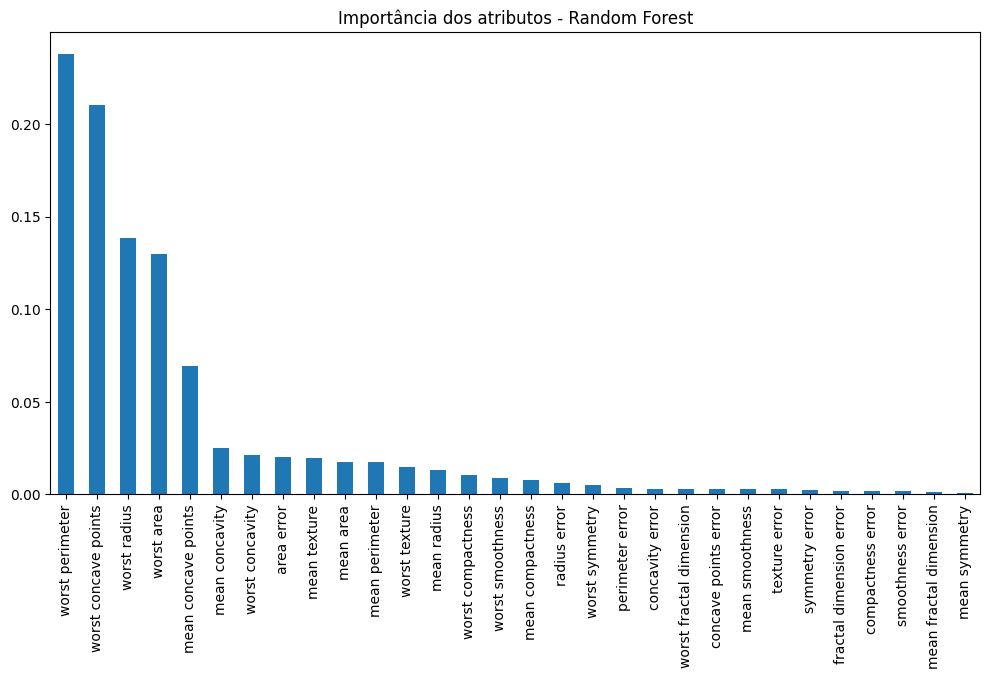

In [ ]:
importances = pd.Series(rf.feature_importances_, index=cancer.feature_names)
importances.sort_values(ascending=False).plot(kind="bar", figsize=(12,6))
plt.title("Importância dos atributos - Random Forest")
plt.show()